### Creating data to view and fit

In [44]:
from  sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [45]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [46]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

Visualizing our created data

In [47]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


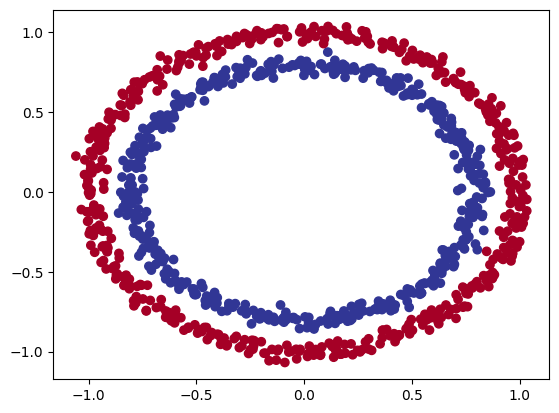

In [48]:
# Visuallize with a plot
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and output shapes

In [49]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [50]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

In [51]:
# how many samples we're working 
len(X), len(y)

(1000, 1000)

In [52]:
# View the first example of features and labels
X[5], y[5]

(array([-0.47964637,  0.67643477]), 1)

### Steps in modelling

In [53]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. Fit the model 
model_1.fit(X, y, epochs=5)

Epoch 1/5


32/32 [==============================] - 1s 1ms/step - loss: 6.2597 - accuracy: 0.4860
Epoch 2/5
32/32 [==============================] - 0s 1ms/step - loss: 6.0666 - accuracy: 0.5000
Epoch 3/5
32/32 [==============================] - 0s 1ms/step - loss: 5.9263 - accuracy: 0.4930
Epoch 4/5
32/32 [==============================] - 0s 1ms/step - loss: 5.7919 - accuracy: 0.4930
Epoch 5/5
32/32 [==============================] - 0s 1ms/step - loss: 5.3471 - accuracy: 0.4950


In [54]:
# Let's try and improve our model by training for longer
model_1.fit(X, y, epochs=200, verbose=0)

In [55]:
# Evaluation
model_1.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5000


[0.6934831142425537, 0.5]

In [56]:
# let's add extra layer

# Set the random seed
tf.random.set_seed(42)

# 1. Create a model, this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [57]:
# 4. Evaluate the model
model_2.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6932 - accuracy: 0.5000


[0.6932393312454224, 0.5]

### Improving our model

In [58]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 2.3483 - accuracy: 0.4580
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 0.7255 - accuracy: 0.4900
Epoch 3/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6978 - accuracy: 0.4620
Epoch 4/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6947 - accuracy: 0.4850
Epoch 5/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6949 - accuracy: 0.4830
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6950 - accuracy: 0.4430
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6948 - accuracy: 0.5020
Epoch 8/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6955 - accuracy: 0.5110
Epoch 9/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6970 - accuracy: 0.4730
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6945 - accuracy: 0.4630
Epoch 11/

In [59]:
# 4. Evaluate the model
model_3.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.7011 - accuracy: 0.5060


[0.7010847330093384, 0.5059999823570251]

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make preditions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falss)

In [60]:
import numpy as np

In [61]:
import numpy as np 
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

  1/313 [..............................] - ETA: 28s

313/313 [==============================] - 0s 1ms/step
doing binary classification


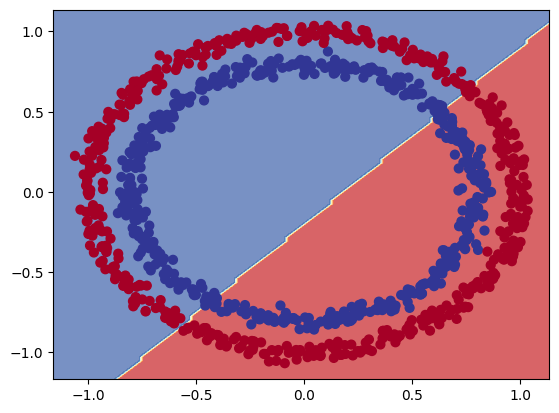

In [62]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

### The missing piece : Non Linearity

In [63]:
# Set tje random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 4.3381 - accuracy: 0.4510
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2982 - accuracy: 0.4500
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2464 - accuracy: 0.4550
Epoch 4/100
32/32 [==============================] - 0s 2ms/step - loss: 4.2415 - accuracy: 0.4550
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2402 - accuracy: 0.4560
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2318 - accuracy: 0.4560
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2262 - accuracy: 0.4570
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2243 - accuracy: 0.4580
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1977 - accuracy: 0.4560
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1445 - accuracy: 0.4600
Epoch 11/

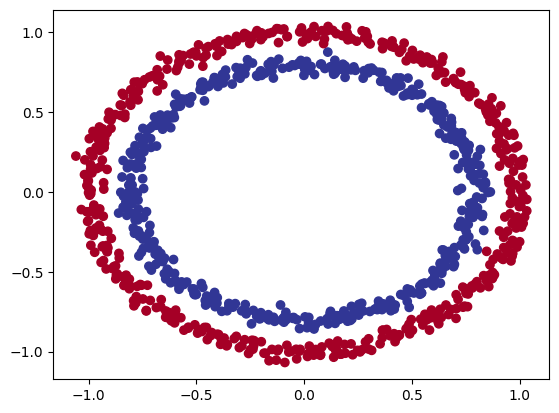

In [64]:
# Check out our data 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 [==============================] - 0s 1ms/step
doing binary classification


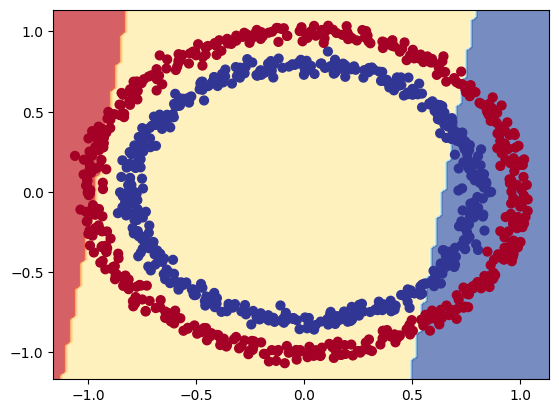

In [65]:
# Check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

### let's try build our first neural network with a non-linear activation function

In [66]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 5.8425 - accuracy: 0.4910
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 5.8143 - accuracy: 0.4890
Epoch 3/100
32/32 [==============================] - 0s 2ms/step - loss: 5.8121 - accuracy: 0.4890
Epoch 4/100
32/32 [==============================] - 0s 3ms/step - loss: 5.8024 - accuracy: 0.4870
Epoch 5/100
32/32 [==============================] - 0s 2ms/step - loss: 5.8078 - accuracy: 0.4860
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 5.8063 - accuracy: 0.4860
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 5.7694 - accuracy: 0.4840
Epoch 8/100
32/32 [==============================] - 0s 2ms/step - loss: 5.7412 - accuracy: 0.4820
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7390 - accuracy: 0.4820
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 5.7375 - accuracy: 0.4830
Epoch 11/

In [67]:
# Time to replicate the multi-layer neural network from TensorFLow playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y, epochs=250)

Epoch 1/250
32/32 [==============================] - 1s 2ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 2/250
32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 3/250
32/32 [==============================] - 0s 2ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 4/250
32/32 [==============================] - 0s 2ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 5/250
32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 6/250
32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 7/250
32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 8/250
32/32 [==============================] - 0s 2ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 9/250
32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 10/250
32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000
Epoch 11/

In [68]:
# Evaluate the model
model_6.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 7.7125 - accuracy: 0.5000


[7.712474346160889, 0.5]

313/313 [==============================] - 0s 1ms/step
doing binary classification


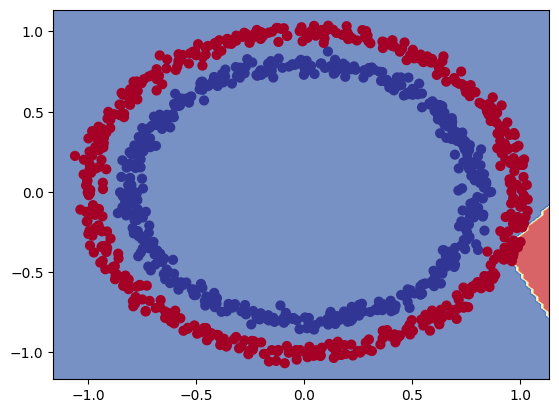

In [69]:
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

In [70]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 0.6960 - accuracy: 0.4980
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6938 - accuracy: 0.5040
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6918 - accuracy: 0.5080
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6907 - accuracy: 0.5080
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6896 - accuracy: 0.5210
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6886 - accuracy: 0.5200
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6877 - accuracy: 0.5280
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6871 - accuracy: 0.5290
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6863 - accuracy: 0.5330
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6857 - accuracy: 0.5290
Epoch 11/

In [71]:
# 4. Evalute the model
model_7.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.5368 - accuracy: 0.7620


[0.5368376970291138, 0.7620000243186951]

313/313 [==============================] - 0s 1ms/step


doing binary classification


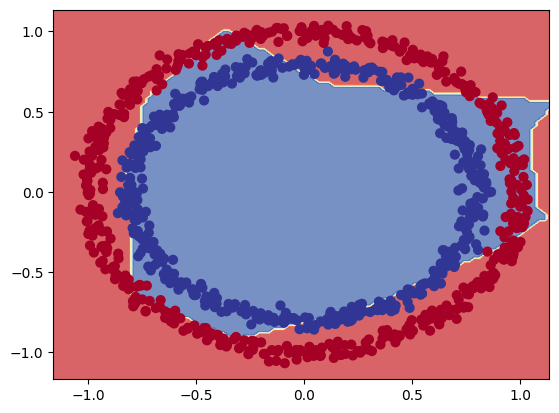

In [72]:
# Let's visualize our model_7
plot_decision_boundary(model_7, X, y)

In [73]:
# Split the dataset into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [74]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") 
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25


25/25 [==============================] - 1s 2ms/step - loss: 0.6961 - accuracy: 0.4775
Epoch 2/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6912 - accuracy: 0.4963
Epoch 3/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6876 - accuracy: 0.5387
Epoch 4/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6861 - accuracy: 0.5238
Epoch 5/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6805 - accuracy: 0.5800
Epoch 6/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6712 - accuracy: 0.5900
Epoch 7/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6593 - accuracy: 0.7600
Epoch 8/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6485 - accuracy: 0.6875
Epoch 9/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6256 - accuracy: 0.7237
Epoch 10/25
25/25 [==============================] - 0s 1ms/step - loss: 0.5887 - accuracy: 0.7788
Epoch 11/25
25/25 [===========

In [75]:
# 4. Evaluate the model
model_8.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.0646 - accuracy: 0.9950


[0.06456796824932098, 0.9950000047683716]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


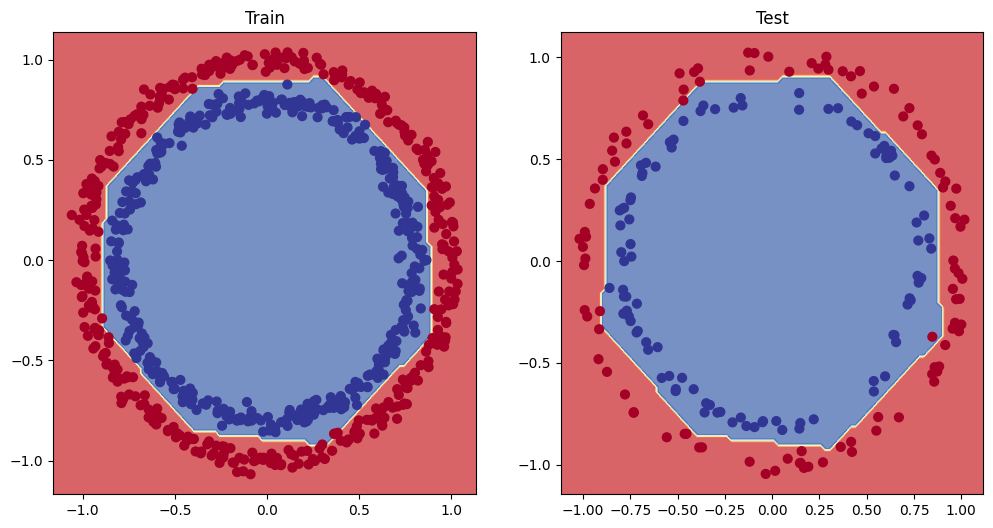

In [76]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X_test, y_test)
plt.show()

### Plotting loss curve

In [77]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,loss,accuracy
0,0.696069,0.47750
1,0.691179,0.49625
2,0.687624,0.53875
3,0.686090,0.52375
4,0.680494,0.58000
5,0.671224,0.59000
6,0.659300,0.76000
7,0.648518,0.68750
8,0.625646,0.72375
9,0.588711,0.77875


Text(0.5, 1.0, 'Model_8 loss curves')

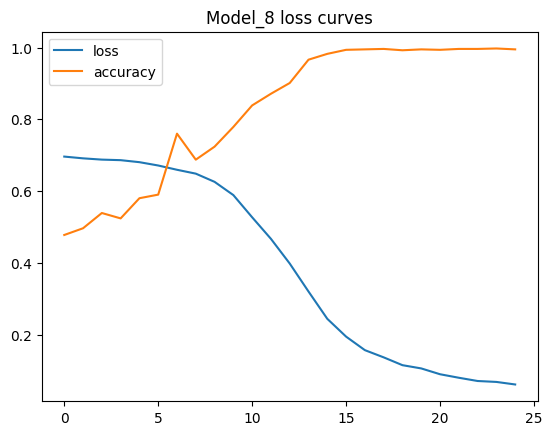

In [78]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves")

## Finding the best learining rate

In [79]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 3. Fit the model (passing lr_scheduler callback)
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 [==============================] - 1s 2ms/step - loss: 0.7528 - accuracy: 0.5113 - lr: 1.0000e-04
Epoch 2/100
25/25 [==============================] - 0s 2ms/step - loss: 0.7504 - accuracy: 0.5125 - lr: 1.1220e-04
Epoch 3/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7480 - accuracy: 0.5088 - lr: 1.2589e-04
Epoch 4/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7453 - accuracy: 0.5125 - lr: 1.4125e-04
Epoch 5/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7425 - accuracy: 0.5125 - lr: 1.5849e-04
Epoch 6/100
25/25 [==============================] - 0s 2ms/step - loss: 0.7398 - accuracy: 0.5075 - lr: 1.7783e-04
Epoch 7/100
25/25 [==============================] - 0s 2ms/step - loss: 0.7368 - accuracy: 0.5038 - lr: 1.9953e-04
Epoch 8/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7338 - accuracy: 0.5050 - lr: 2.2387e-04
Epoch 9/100
25/25 [==============================] - 0s 1ms/step - loss:

<Axes: xlabel='epochs'>

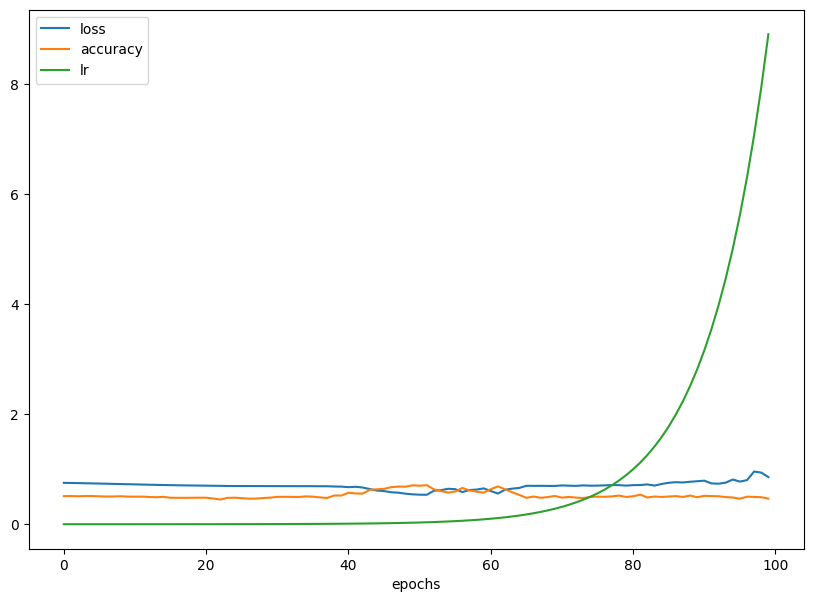

In [80]:
# Checout the history
pd.DataFrame(history_9.history).plot(figsize=(10, 7), xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

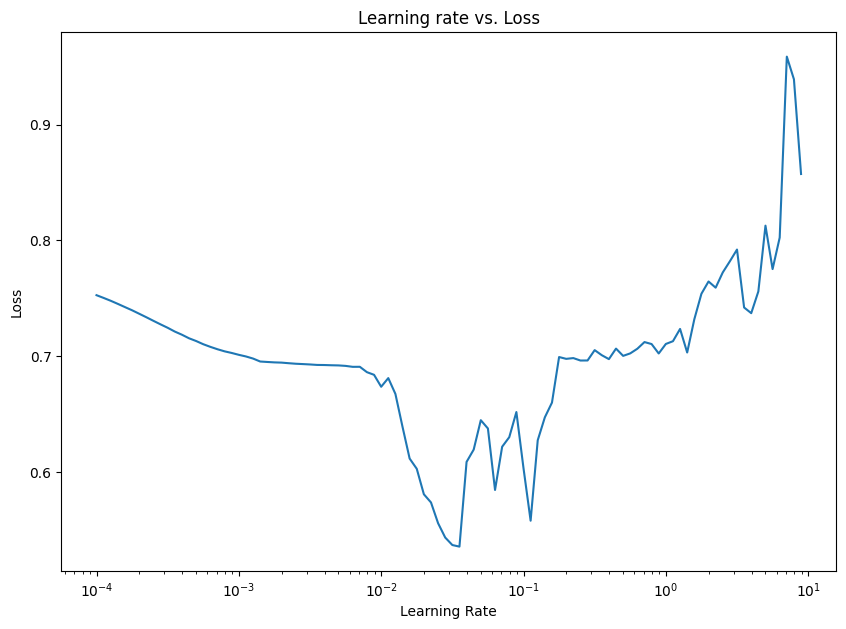

In [81]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")

In [82]:
# Let's try using a higher ideal learning rate with the same model as before

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model with the ideal learning rate
model_10.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                   metrics=["accuracy"])

# Fit the model for 20 epochs (5 less than before)
history_10 = model_10.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 [==============================] - 1s 1ms/step - loss: 0.7068 - accuracy: 0.4863
Epoch 2/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6939 - accuracy: 0.4863
Epoch 3/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6933 - accuracy: 0.4963
Epoch 4/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6934 - accuracy: 0.5013
Epoch 5/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5013
Epoch 6/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6942 - accuracy: 0.4963
Epoch 7/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6929 - accuracy: 0.5063
Epoch 8/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5013
Epoch 9/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6939 - accuracy: 0.5013
Epoch 10/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6934 - accuracy: 0.4938
Epoch 11/20
25/25 [

In [83]:
# 4. Evaluate model_10 on the test dataset
model_10.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.4950


[0.6931580901145935, 0.4950000047683716]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


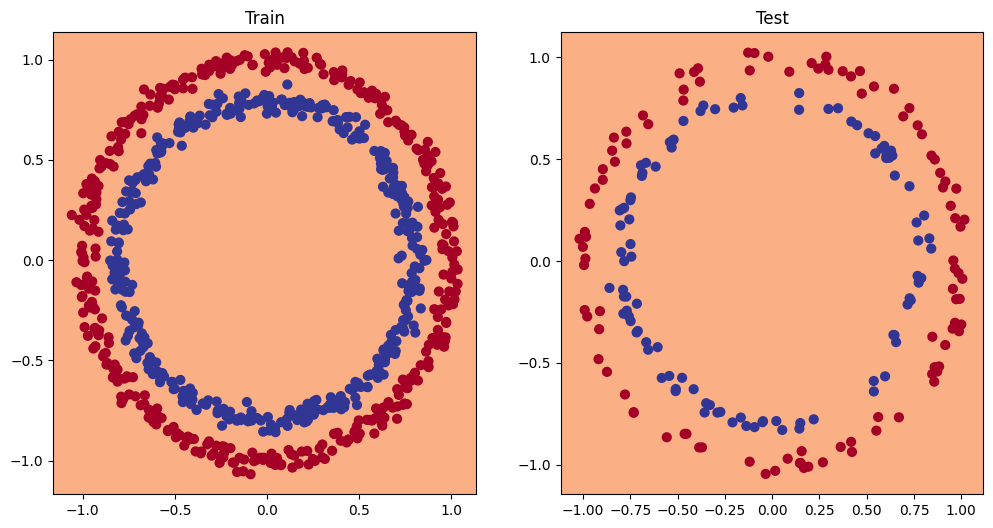

In [84]:
# plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_10, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_10, X_test, y_test)
plt.show()

In [85]:
# Check the accuracy of our model.
loss, accuracy = model_10.evaluate(X_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {(accuracy*100):.2f}%")

7/7 [==============================] - 0s 1ms/step - loss: 0.6932 - accuracy: 0.4950
Model loss on the test set: 0.6931580901145935
Model accuracy on the test set: 49.50%


How about a confusion matrix?

In [86]:
# # Create a confusion matrix
# from sklearn.metrics import confusion_matrix

# # Make predictions
# y_preds = model_10.predict(X_test)

# # Create confusion matrix
# confusion_matrix(y_test, y_preds)

In [87]:
y_test[:10]

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

In [88]:
y_preds[:10]

array([[0.99851894],
       [0.9990452 ],
       [0.998041  ],
       [0.9969982 ],
       [0.07440898],
       [0.07351813],
       [0.97043496],
       [0.00198834],
       [0.9979249 ],
       [0.1208379 ]], dtype=float32)

Looks like our predictions array has come out in prediction probability form... the standard output from the sigmoid (or softmax) activation function.

In [89]:
# Convert prediction probabilities to binary format and view the first 10
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [90]:
# Create a confusion matrix
confusion_matrix(y_test, tf.round(y_preds))

array([[99,  2],
       [ 0, 99]], dtype=int64)

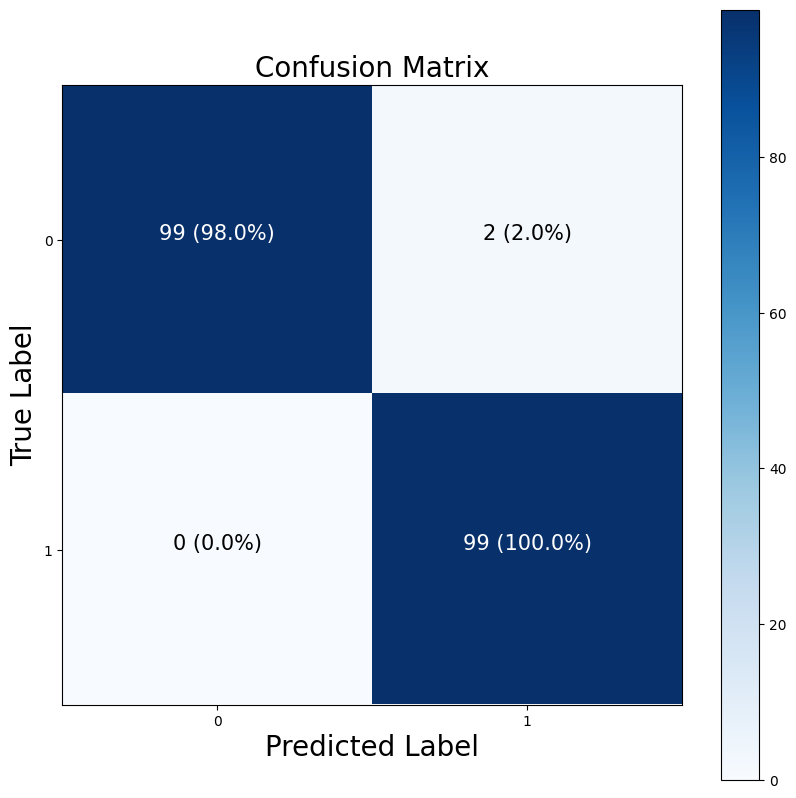

In [91]:
# Prettify our confusion matrix

import itertools

figsize = (10, 10)

# Create the confusion matrix
cm = confusion_matrix(y_test, tf.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize our confusion matrix
n_classes = cm.shape[0]

# let's prettify it 
fig, ax = plt.subplots(figsize=figsize)

# Create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# Create classes
classes = False

if classes:
    labels = classes
else:
    labels = np.arange(cm.shape[0])
    
    
# label the axes
ax.set(title="Confusion Matrix",
       xlabel="Predicted Label",
       ylabel="True Label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set x-axis labels to bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)

# Set threshold for different colors
threshold = (cm.max() + cm.min()) / 2

# Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=15)

# Working with a larger example (multiclass classification)

When you have more than two classes as an option, it's known as **multi-class classification**.
* this means if you have 3 different classes, it's multi-class classification.
* It also means if you have 100 different classes, it's multi-class classificaiton.

In [92]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [93]:
# Show the first training example
print(f"Training sample:\n{train_data[0]}\n")
print(f"Trining label:\n{train_labels[0]}\n")

Training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [94]:
# Check the shape of a single example
train_data[0].shape, train_labels[0].shape

((28, 28), ())

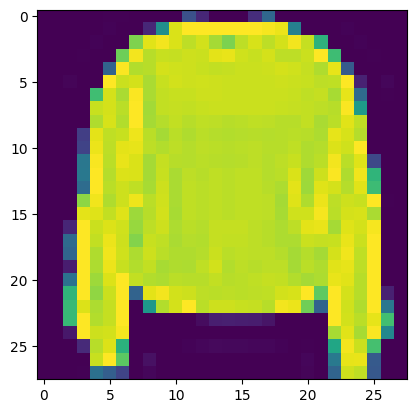

In [95]:
# Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7])

In [96]:
# Check out samples label
train_labels[7]

2

In [97]:
# Create a small list so we can index onto our training labels so they're human-readable
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankel boot"]

len(class_names)

10

Text(0.5, 1.0, 'Sandal')

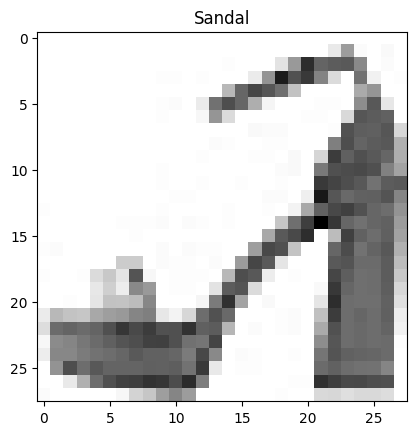

In [98]:
# Plot an example image and its label
index_of_choice = 172
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

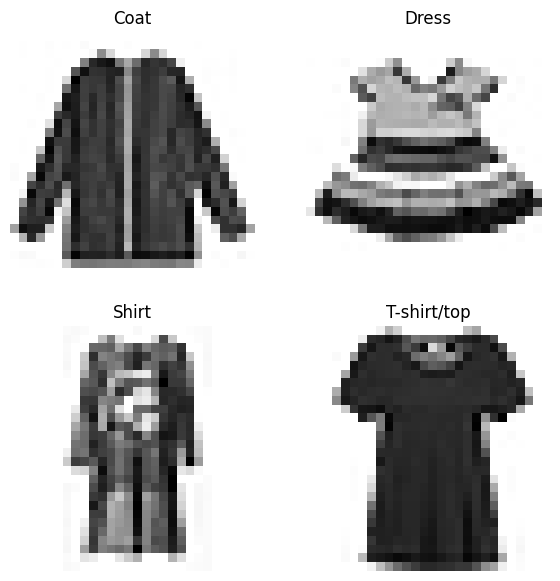

In [99]:
# Plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7, 7))
for i in range(4):
    ax = plt.subplot(2, 2, i+1)
    rand_index = random.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[rand_index]])
    plt.axis(False)

## Building a multi-class classification model

For our multi-class classification model, we can use a similar architecture to our binary classifier, however, we're going to have to tweak a few things:
* Input shape = 28 x 28 (the shape of one image)
* Output shape = 10 (one per class of clothing)
* Loss function = tf.keras.losses.CategoricalCrossentropy()
    * If your labels are one-hot encoded, use CategoricalCrossentropy()
    * If your labels are integer form use SparseCategoricalCrossentropy()
* Output layer activation = Softmax 

In [100]:
# Set random seed
tf.random.set_seed(42)

# !. Create the model
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

# 2. Compile the model
model_11.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# 3. Fit the model
non_norm_history = model_11.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))

Epoch 1/10


1875/1875 [==============================] - 4s 2ms/step - loss: 2.4777 - accuracy: 0.0985 - val_loss: 2.3001 - val_accuracy: 0.1000
Epoch 2/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.2397 - accuracy: 0.1306 - val_loss: 2.1528 - val_accuracy: 0.1626
Epoch 3/10
1875/1875 [==============================] - 3s 2ms/step - loss: 1.9594 - accuracy: 0.2036 - val_loss: 1.7922 - val_accuracy: 0.2264
Epoch 4/10
1875/1875 [==============================] - 3s 2ms/step - loss: 1.7415 - accuracy: 0.2537 - val_loss: 1.7027 - val_accuracy: 0.2627
Epoch 5/10
1875/1875 [==============================] - 3s 2ms/step - loss: 1.6869 - accuracy: 0.2694 - val_loss: 1.6711 - val_accuracy: 0.2728
Epoch 6/10
1875/1875 [==============================] - 3s 2ms/step - loss: 1.6388 - accuracy: 0.2867 - val_loss: 1.5802 - val_accuracy: 0.3158
Epoch 7/10
1875/1875 [==============================] - 3s 2ms/step - loss: 1.5707 - accuracy: 0.3194 - val_loss: 1.5548 - val_accuracy: 0.3487
Epo

In [101]:
# Check the model summary
model_11.summary()

Model: "sequential_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_46 (Dense)            (None, 4)                 3140      
                                                                 
 dense_47 (Dense)            (None, 4)                 20        
                                                                 
 dense_48 (Dense)            (None, 10)                50        
                                                                 
Total params: 3210 (12.54 KB)
Trainable params: 3210 (12.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [102]:
# Check the min and max values of the training data
train_data.min(), train_data.max()

(0, 255)

In [103]:
# We can get our training and testing data between 0 and 1 by dividing by the maximum
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

# Check the min and max values of the scaled training data
train_data_norm.min(), train_data_norm.max()

(0.0, 1.0)

In [104]:
# now our dat is normalized, let's build a model to find patterns in it

# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_11)
model_12 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_12.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# 3. Fit the model
norm_history = model_12.fit(train_data_norm, train_labels, epochs=10, validation_data=(test_data_norm, test_labels))

<Axes: title={'center': 'Normalized Data'}>

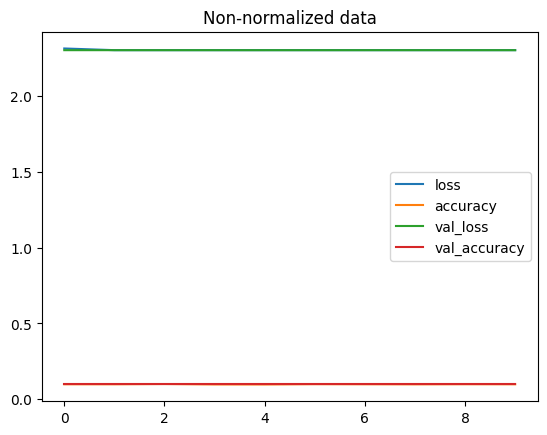

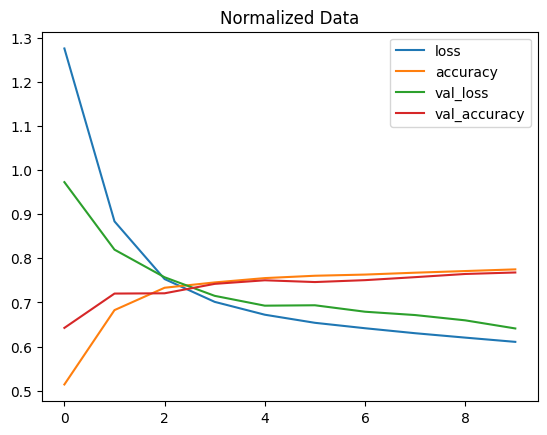

In [ ]:
import pandas as pd
# Plot non-normalized data loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")
# Plot normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Normalized Data")

## Finding the ideal learning rate

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_13.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# Create the learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))

# 3. Fit the model
find_lr_history = model_13.fit(train_data_norm,
                               train_labels,
                               epochs=40,validation_data=(test_data_norm, test_labels),
                               callbacks=[lr_scheduler])

Epoch 1/40
1875/1875 [==============================] - 4s 2ms/step - loss: 1.2429 - accuracy: 0.5438 - val_loss: 0.8501 - val_accuracy: 0.6995 - lr: 0.0010
Epoch 2/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7555 - accuracy: 0.7365 - val_loss: 0.7192 - val_accuracy: 0.7512 - lr: 0.0011
Epoch 3/40
1875/1875 [==============================] - 3s 1ms/step - loss: 0.6791 - accuracy: 0.7619 - val_loss: 0.6899 - val_accuracy: 0.7628 - lr: 0.0013
Epoch 4/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6433 - accuracy: 0.7751 - val_loss: 0.6547 - val_accuracy: 0.7757 - lr: 0.0014
Epoch 5/40
1875/1875 [==============================] - 3s 1ms/step - loss: 0.6232 - accuracy: 0.7829 - val_loss: 0.6459 - val_accuracy: 0.7746 - lr: 0.0016
Epoch 6/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6089 - accuracy: 0.7875 - val_loss: 0.6469 - val_accuracy: 0.7788 - lr: 0.0018
Epoch 7/40
1875/1875 [==============================] - 3s

Text(0.5, 1.0, 'Finding the ideal learning rate')

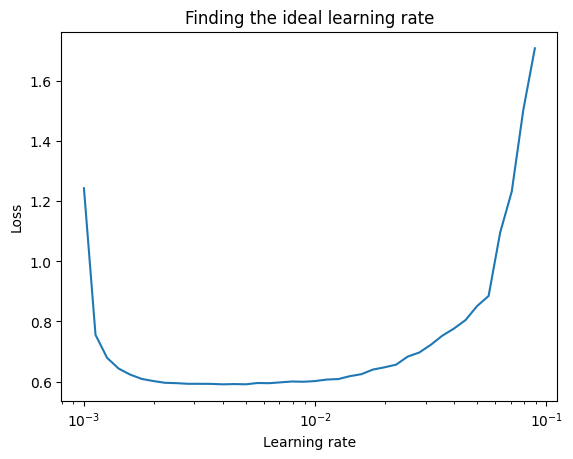

In [ ]:
# plot the learning rate decay curve
import numpy as np
import matplotlib.pyplot as plt 

lrs = 1e-3 * (10**(tf.range(40)/20))
plt.semilogx(lrs, find_lr_history.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")

In [ ]:
# let's refit a model with the ideal learning rate

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_14.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                 metrics=["accuracy"])

# 3. fit the model
history_14 = model_14.fit(train_data_norm,
                          train_labels,
                          epochs=20,
                          validation_data=(test_data_norm, test_labels))

Epoch 1/20
1875/1875 [==============================] - 4s 2ms/step - loss: 1.0383 - accuracy: 0.6090 - val_loss: 0.7478 - val_accuracy: 0.7202
Epoch 2/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6753 - accuracy: 0.7509 - val_loss: 0.6418 - val_accuracy: 0.7658
Epoch 3/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6047 - accuracy: 0.7814 - val_loss: 0.6047 - val_accuracy: 0.7836
Epoch 4/20
1875/1875 [==============================] - 3s 1ms/step - loss: 0.5763 - accuracy: 0.7919 - val_loss: 0.5982 - val_accuracy: 0.7862
Epoch 5/20
1875/1875 [==============================] - 3s 1ms/step - loss: 0.5622 - accuracy: 0.7980 - val_loss: 0.5895 - val_accuracy: 0.7889
Epoch 6/20
1875/1875 [==============================] - 3s 1ms/step - loss: 0.5488 - accuracy: 0.8039 - val_loss: 0.5757 - val_accuracy: 0.7944
Epoch 7/20
1875/1875 [==============================] - 3s 1ms/step - loss: 0.5403 - accuracy: 0.8080 - val_loss: 0.5755 - val_accuracy: